# AP 155 Lab Exercise
---
## Exercise 1: Numbers in Computers

_Instructions_: 
- **Report figure (Problem 1):** Answer and follow the (Modified) Gezerlis 2.6
- **Report figure (Problem 2):** Answer and follow the (Modified) Gezerlis 2.8

### Student Information
- _Full Name (Last Name, First Name)_: Gonzaga, Thomas
- _Student No._: 2023-16222
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

![Figure 1](Loss_of_precision_in_the_bad_quadratic_formula.png)

As seen in the plot, the rising jagged peaks are the result of the float64s precision while float64 present only a flat line as it ran out of precision way before float64. Problem 1 essentially shows us that we need to work around the loss in precision when dealing with equations and functions that involve subtracting numbers with values that are very close with one another.

### Problem 2 Part 1

![Figure 2](Plot_of_f(x)_from_0.1_to_10.png)

The figure illustrates the expected behavior of the $f(x) = \frac{1-\cos x}{x^2}$ as the x approaches zero the plot smoothly approaches 0.5, this give us a general idea on the behavior of the graph.

![Figure 3](Direct_Computation_vs_Applying_Trigonometric_Identity.png)

The second part involves code that compared the difference in precision when directly evaluating the equation and avoiding cancellation. It was found that when directly evaluating the function results in a catastrophic cancellation around $10^(-8)$ which is right where the 64-bit precision starts to fail. Despite using the 64-bits we still can bypass this cancellation by using trigonometric identities to avoid cancellation. 

### Problem 2 Part 2

![Figure 4](Catastrophic_Cancellation_in_f(x).png)

In part 2 we further investigated "catastrophic cancellation" using $f(x) = \frac{e^x - 1}{x}$ and applying NumPys special functions and direct evaluation. It was found that the $e^x$ part of the equation start to approach a number very close to 1 when $x$ approaches 0. This in turn causes catastrophic cancellation similar to part 1. This time, it was fixed by using NumPy's special function `np.expm1(x)`. A figure was then plotted to show the error comparison between directly evaluating it and using the `np.expm1(x)` function. After also generating 16-bit, 32-bit, 64-bit, and 128-bit versions it was found that `np.expm1(x)` most likely uses a 128-bit or higher precision as the 128-bit precision lines up with the `np.expm1(x)` baseline.

### Other comments
- I had problems presenting multiple plots in a singular graph, I kept getting multiple separate graphs
- Learned alot about what floats are and what they do

---
## Section 2: Code

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)

Take the standard quadratic equation: $ax^2 + bx + c = 0$, whose solutions are 

$$x_{\pm}=\frac{-b \pm \sqrt{b^2-4ac}}{2a}$$

Take $b>0$ for concreteness. It is easy to see that when $b^2 >> ac$, we don't get a catastrophic cancellation when evaluating $b^2 - 4ac$ (we may still get a "benign" cancellation). Furthermore, $\sqrt{b^2-4ac} \approx b$. 

However, this means that $x_+$ will involve catastrophic cancellation in the numerator. We will employ an analytical trick in order to help us preserve significant figures. Observe that the product of the two roots must obey 

$$x_+ x_- = \frac{c}{a}$$

The answer now presents itself: use the standard quadratic formula to calculate $x_-$, for which no catastrophic cancellation takes place. Then, use $x_+ x_- = \frac{c}{a}$ to calculate $x_+$. Notice that you end up calculating $x_+$, via division only (i.e. without a catastrophic cancellation). 

Write a Python code (use `np.sqrt()`) that evaluates and prints out **(a)** $x_-$, **(b)** $x_+$ using the "bad formula", and **(c)** $x_+$ using the "good formula". 

Take $a=1$, $c=1$, $b=10^8$. Discuss the answers.

Lastly, **(d)** [FIGURE] Visualize the loss of precision by plotting the relative error of the "bad" $x_+$ formula. Vary $b$ using a log scaling (e.g., from $10^4$ to $10^9$). To highlight the effect of hardware limits, evaluate the bad formula using both 32-bit (np.float32) and 64-bit (np.float64) precision, comparing them against the "good" formula as the baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# Evaluating and Printing (a) and (b)
a = 1
b = 10**8
c = 1

inside_square_root = b**2 - 4*a*c
print("discriminant =", inside_square_root)

x_positive = (-b + np.sqrt(inside_square_root)) / (2*a)
x_negative = (-b - np.sqrt(inside_square_root)) / (2*a)

# I wanted to present it in a readbale way that you can see the difference in values
print(f"bad positive x = {x_positive:.12f} (should be 0)")
print("bad negative x =", x_negative)

discriminant = 9999999999999996
bad positive x = -0.000000007451 (should be 0)
bad negative x = -100000000.0


#### Deriving "good formula" x

from the equation:
$$x_+ x_- = \frac{c}{a}$$
we can derive (by dividing $x_-$ on both sides):
$$x_+ = \frac{c}{a*(x_-)}$$
we can use this instead of the "bad formula" for x

In [3]:
# Evaluating (c)
# instead of calculating x_positive directly we can derive it from x_negative instead

good_x_positive = c / (a*x_negative)

print(f"good positive x = {good_x_positive:.12f}")

good positive x = -0.000000010000


In [4]:
# we are basically doing the first part but limiting them to 64 bits
b_values = np.logspace(4, 9, 100)

errors64 = []

for b in b_values:

    # tells computer to use exactly 8 bytes of memory (64 bits)
    a64 = np.float64(1)
    b64 = np.float64(b)
    c64 = np.float64(1)

    discriminator64 = b64**2 - 4*a64*c64

    bad_x_positive_64 = (-b64 + np.sqrt(discriminator64)) / (2*a64)
    x_negative_64 = (-b64 - np.sqrt(discriminator64)) / (2*a64)
    good_x_positive_64 = c64 / (a64*x_negative_64)
    
    # error
    error64 = abs((bad_x_positive_64 - good_x_positive_64) / good_x_positive_64)
    errors64.append(error64)

# I wanted to present it in a readbale way that you can see the difference in values
print(f"64-bit discriminator = {discriminator64:12f}")
print(f"64 bit bad positive x = {bad_x_positive_64:.12f}")
print(f"64 bit negative x = {x_negative_64:.12f}")
print(f"64 bit good positive x = {good_x_positive_64:.12f}")

64-bit discriminator = 1000000000000000000.000000
64 bit bad positive x = 0.000000000000
64 bit negative x = -1000000000.000000000000
64 bit good positive x = -0.000000001000


In [5]:
# we are basically doing the first part but limiting them to 32 bits
b_values = np.logspace(4, 9, 100)

errors32 = []

for b in b_values:

    # tells computer to use exactly 7 bytes of memory (32 bits)
    a32 = np.float32(1)
    b32 = np.float32(b)
    c32 = np.float32(1)
    four32 = np.float32(4)
    two32 = np.float32(2)

    discriminator32 = b32**two32 - four32*a32*c32

    bad_x_positive_32 = (-b32 + np.sqrt(discriminator32)) / (two32*a32)
    x_negative_32 = (-b32 - np.sqrt(discriminator32)) / (two32*a32)
    good_x_positive_32 = c32 / (a32*x_negative_32)

    # showing error
    error32 = abs((bad_x_positive_32 - good_x_positive_32) / good_x_positive_32)
    errors32.append(error32)

# I wanted to present it in a readbale way that you can see the difference in values
print(f"32-bit discriminator = {discriminator32:12f}")
print(f"32 bit bad positive x = {bad_x_positive_32:.12f}")
print(f"32 bit negative x = {x_negative_32:.12f}")
print(f"32 bit good positive x = {good_x_positive_32:.12f}")

# most notable difference between the 64-bit precision is the discriminator value

32-bit discriminator = 999999984306749440.000000
32 bit bad positive x = 0.000000000000
32 bit negative x = -1000000000.000000000000
32 bit good positive x = -0.000000001000


In [6]:
# make sure that the length of these variables are the same so that the plot works
print(len(b_values))
print(len(errors64))
print(len(errors32))

100
100
100


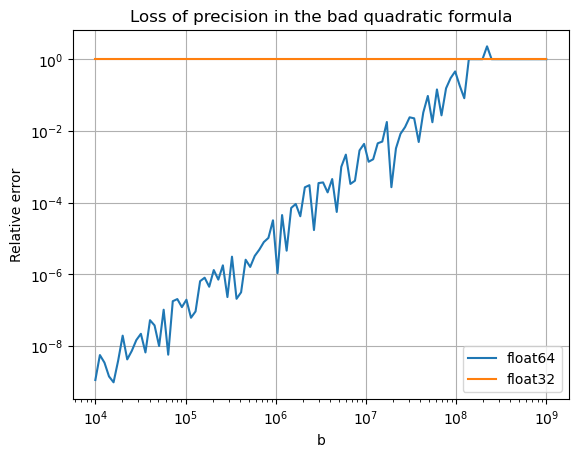

In [7]:
# plots the two lines on the same graph
plt.loglog(b_values, errors64, label="float64")
plt.loglog(b_values, errors32, label="float32")

# labels
plt.xlabel("b")
plt.ylabel("Relative error")
plt.title("Loss of precision in the bad quadratic formula")
plt.legend()
plt.grid(True)

# saves the image
plt.savefig('Loss_of_precision_in_the_bad_quadratic_formula.png', dpi=150)
plt.show()
plt.close()

#### Problem 1 code summary

Following the flow of questions, I wrote the code in such a way where variables are defined in previous cells and then called back when needed in the following follow-up questions. I also made sure that all the necessary points and numbers were presented so that you can see the progression and reasoning behind writing certain scripts.

### Problem 2: Singularity (Gezerlis 2.8)

#### Part 1:

We will study the following function:

$$f(x) = \frac{1-\cos x}{x^2}$$

**(a)** Start by plotting the function, with a step size of $0.1$ from $x=0.1$ to $x=10$. This should give you some idea of the values you should expect for $f(x)$ at small $x$. You can do this by using `np.arange()` to generate a `numpy array` that you will feed to a function that you will define.

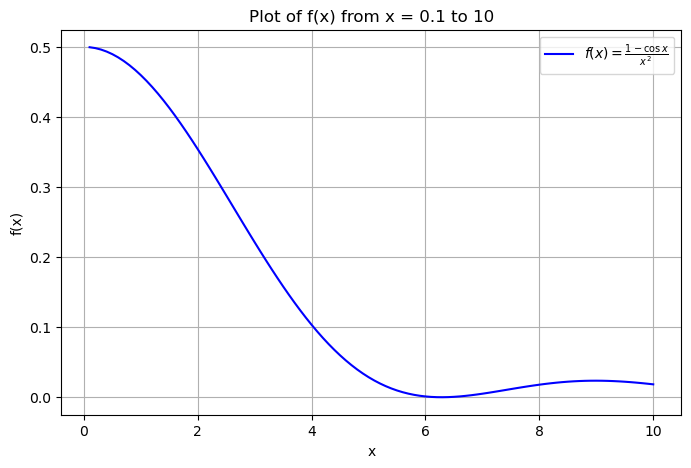

In [8]:
# generating base array
step_size = 0.1
x = np.arange(0.1, 10.0 + step_size, step_size)

def f(x):
    return (1 - np.cos(x)) / (x**2)

y = f(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r"$f(x) = \frac{1 - \cos x}{x^2}$",color="blue")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Plot of f(x) from x = 0.1 to 10")
plt.grid(True)
plt.legend()

plt.savefig('Plot_of_f(x)_from_0.1_to_10.png', dpi=150)
plt.show()
plt.close()

**(b)** Verify your previous hunch by taking the limit as $x \longrightarrow 0$ and using L'Hopital's rule. You will submit this at the end of the class on a piece of paper.

**(c)** Now, see what value you find for $f(x)$ when $x=1.2 \times 10^{-8}$. Does this make sense qualitatively?

In [9]:
f((1.2)*(10**(-8)))

0.7709882115452477

In [10]:
# Now we cant really read the last result so heres a version for humans
result_human = int(f((1.2)*(10**(-8))))
print("Human-Friendly Result =", result_human)

# now this result makes sense qualitatively

Human-Friendly Result = 0


**(d)** Use a trigonometric identity to avoid the cancellation. Evaluate the new function at $x=1.2 \times 10^{-8}$ and compare with your analytical answer for $x \longrightarrow 0$.

**(e)** [FIGURE] Produce a figure that compares how $f(x)$ approaches a certain value as $x \longrightarrow 0$, between directly computing $f(x)$ and by using a trigonometric identity to "avoid the cancellation". 

In [11]:
# (d) making a function after applying the trogonometric identity
def f_clean(x):
    # i keep forgetting to put return
    return(2 * (np.sin(x/2))**2) / x**2

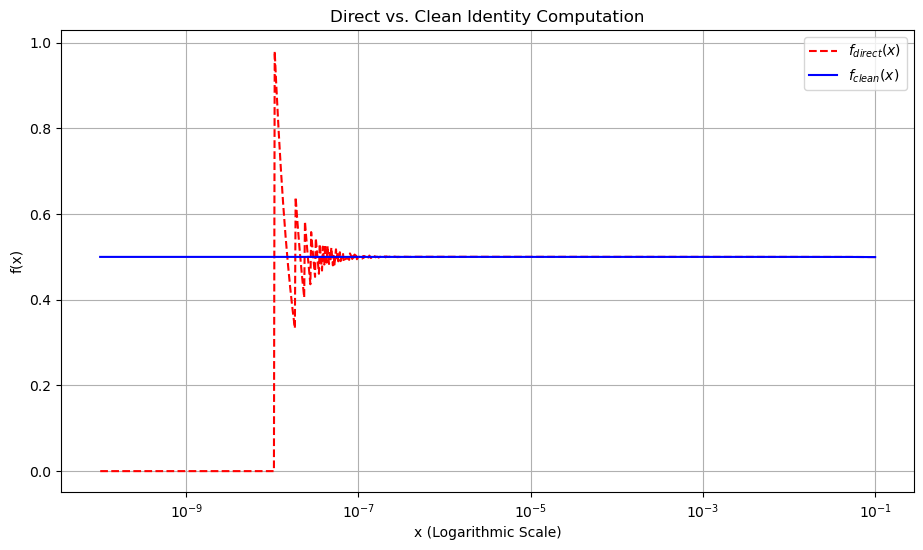

In [12]:
# (e) creating a plot
step_size = 0.1
x = np.arange(0.1, 10.0 + step_size, step_size)

def f_direct(x):
    return (1 - np.cos(x)) / (x**2)

# creating a log space for x
x_log = np.logspace(-1, -10, 1000)

plt.figure(figsize=(11, 6))

plt.plot(x_log, f_direct(x_log), label=r"$f_{direct}(x)$", color="red", linestyle="--")
plt.plot(x_log, f_clean(x_log), label=r"$f_{clean}(x)$", color="blue")
plt.xscale('log')
plt.xlabel("x (Logarithmic Scale)")
plt.ylabel("f(x)")
plt.title("Direct vs. Clean Identity Computation")
plt.grid(True)
plt.legend()
plt.savefig('Direct_Computation_vs_Applying_Trigonometric_Identity.png', dpi=150)
plt.show()
plt.close()

**Bonus**: also compare part with different hardware floating-point precisions: 16/32/64/128-bit. 

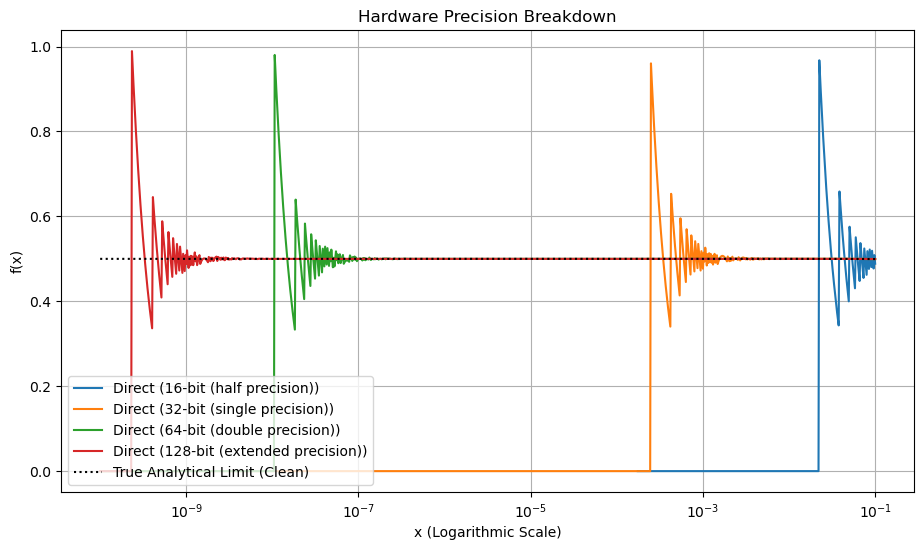

In [13]:
# Dictionary of precisions
precisions = {
    "16-bit (half precision)": np.float16,
    "32-bit (single precision)": np.float32,
    "64-bit (double precision)": np.float64,
    "128-bit (extended precision)": np.longfloat 
}

plt.figure(figsize=(11, 6))

with np.errstate(divide='ignore', invalid='ignore'): # Suppress the float16 underflow warnings
    for label, dtype in precisions.items():
        x_typed = x_log.astype(dtype)
        y_direct = f_direct(x_typed)
        plt.plot(x_log, y_direct, label=f"Direct ({label})")

# adding baseline
y_clean = f_clean(x_log.astype(np.longfloat))
plt.plot(x_log, y_clean, label="True Analytical Limit (Clean)", color="black", linestyle=":")

plt.xscale('log')
plt.xlabel("x (Logarithmic Scale)")
plt.ylabel("f(x)")
plt.title("Hardware Precision Breakdown")
plt.grid(True)
plt.legend(loc="lower left")

plt.savefig('Hardware_Precision_Breakdown.png', dpi=150)
plt.show()
plt.close()

#### Part 2:

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

**(a)** For which values of x does the catastrophic cancellation occur?
    
Catastrophic cancellation occurs when x is very close to 0. As x approaches 0, $e^x \approx 1$. When we do this the computer is forced to compute the difference between two nearly identical numbers losing precision.

**(b)**  How can we resolve the catastrophic cancellation?

using `np.expm1(x)` we can avoid this catastrophic cancellation. This is NumPy's specialized floating-point function designed specifically to calculate $e^x - 1$ accurately for very small values of $x$.

**(c)**  [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

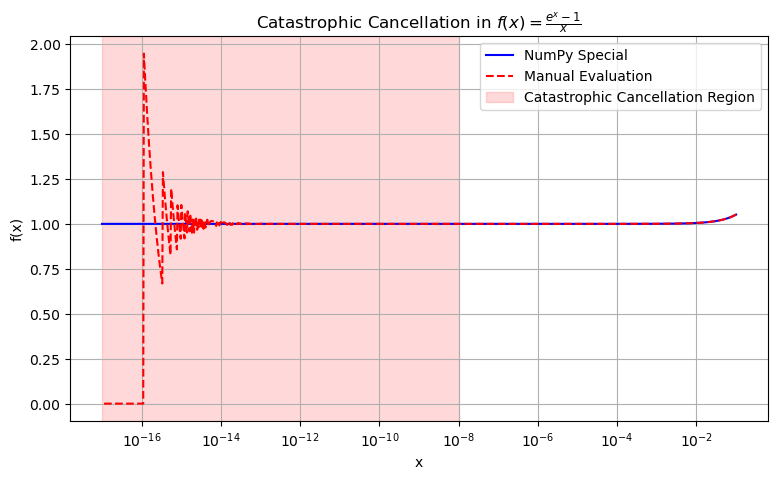

In [14]:
# manual evaluation
def f_manual(x):
  return (np.exp(x) - 1) / x

# numerically stable evaluation using np.expm1
def f_stable(x):
  return np.expm1(x) / x

# Define x sequence from 10^-1 down to 10^-17
x = np.logspace(-1, -17, 1000)

# Calculate values
y_manual = f_manual(x)
y_stable = f_stable(x)

plt.figure(figsize=(9, 5))

# Plot stable vs manual
plt.plot(x, y_stable, label="NumPy Special", color="blue")
plt.plot(x, y_manual, label="Manual Evaluation", color="red", linestyle="--")

# Labels
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Catastrophic Cancellation in $f(x) = \\frac{e^x - 1}{x}$")
plt.grid(True)

# Highlight cancellation region
plt.axvspan(
    1e-17,
    1e-8,
    color="red",
    alpha=0.15,
    label="Catastrophic Cancellation Region",
)

plt.xscale("log")

plt.legend()
plt.savefig("Catastrophic_Cancellation_in_f(x).png", dpi=150)
plt.show()
plt.close()

# the code computes both the stable evaluation using the NumPy special thing and compares it with the computed manual evaluation
# both of these values are plotted against a logspace of x
# other notable values were then added to show where the cancellation region occurs

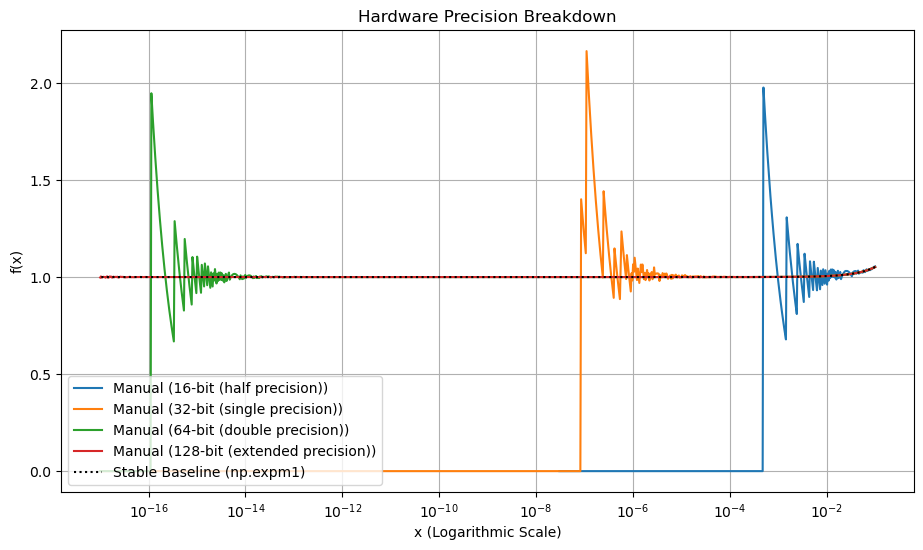

In [15]:
# Dictionary of precisions
precisions = {
    "16-bit (half precision)": np.float16,
    "32-bit (single precision)": np.float32,
    "64-bit (double precision)": np.float64,
    "128-bit (extended precision)": np.longfloat 
}

plt.figure(figsize=(11, 6))

with np.errstate(divide='ignore', invalid='ignore'): # Suppress the float16 underflow warnings
    for label, dtype in precisions.items():
        x_typed = x.astype(dtype)
        y_manual = f_manual(x_typed)
        plt.plot(x, y_manual, label=f"Manual ({label})")

# adding baseline
y_stable = f_stable(x.astype(np.longfloat))
plt.plot(x, y_stable, label="Stable Baseline (np.expm1)", color="black", linestyle=":")

plt.xscale('log')
plt.xlabel("x (Logarithmic Scale)")
plt.ylabel("f(x)")
plt.title("Hardware Precision Breakdown")
plt.grid(True)
plt.legend(loc="lower left")

plt.savefig('Hardware_Precision_Breakdown.png', dpi=150)
plt.show()
plt.close()

# 128 bit precision is very close to the true stable baseline

#### Problem 2 code summary

The first code (a) basically just illustrates and gives us a general idea of how the plot of $f(x) = \frac{1-\cos x}{x^2}$ would behave. The code in part 1 and part 2 that calculates the error comparisons of different methods follow very similar structure. It basically just defines two functions (one direct evaluation and one with the workaround) and compares the two in a plot.

---
## Section 3: Background

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [17]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [18]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [19]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [20]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [21]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [22]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [23]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [24]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [25]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [26]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [27]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [28]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [29]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [30]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [31]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [32]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [33]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

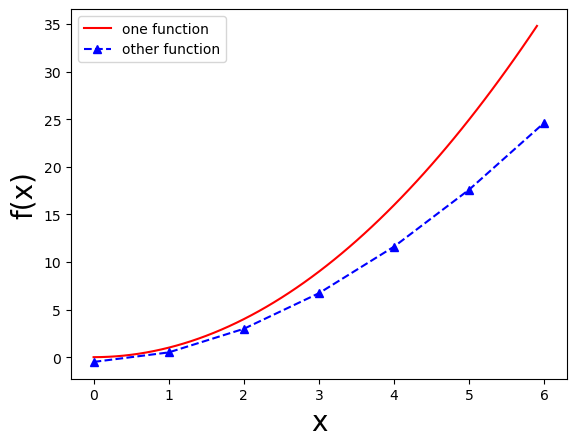

In [35]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

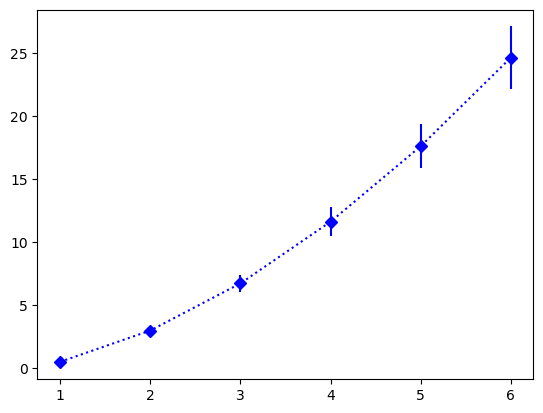

In [36]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [37]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [38]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])